# PyGIMLi reference model from shared karst survey YAML

This notebook runs the **oversampled reference model** for the karst/cave survey.

Reference geometry:

- Cave centre at `x = 0 m`
- Cabled geophones from `-75` to `+75 m` at `1 m` spacing: **151 receivers**
- Shots from `-100` to `+100 m` at `1 m` spacing: **201 shots**
- Maximum source-receiver offset: **175 m**

The goal is to compute the full no-cave and with-cave first-arrival travel-time
datasets once, save them, and then use those tables later for decimation tests:

- remove shots
- remove receivers
- reduce aperture
- emulate 4 m SmartSolo spacing
- compare dense versus sparse survey geometries

The notebook uses a fine reference mesh, including extra refinement in and around
the cave. Later coarser meshes can be compared against this reference to quantify
numerical degradation.

In [1]:
from pathlib import Path
import copy
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pygimli as pg
import pygimli.meshtools as mt
import pygimli.physics.traveltime as tt


pg.utils.units.quants["vel"]["cMap"] = "inferno_r"

## 1. Load shared YAML configuration

By default this notebook first looks for the centred cave/array YAML, then falls
back to the original `karst_survey_config_v3.yml`.

In [2]:
# Prefer the centred geometry if available.
candidate_config_files = [
    Path("karst_reference_oversampled_survey.yml"),
    Path("karst_survey_config_centered_cave_array.yml"),
    Path("/mnt/data/karst_survey_config_centered_cave_array.yml"),
    Path("karst_survey_config_v3.yml"),
    Path("/mnt/data/karst_survey_config_v3.yml"),
]

CONFIG_FILE = next((p for p in candidate_config_files if p.exists()), None)
if CONFIG_FILE is None:
    raise FileNotFoundError("Could not find a karst survey YAML configuration file.")

with CONFIG_FILE.open("r") as f:
    cfg = yaml.safe_load(f)

OUTPUT_DIR = Path(cfg.get("output", {}).get("dir", "karst_model_output")) / "pygimli"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Using config: {CONFIG_FILE}")
print(f"Output directory: {OUTPUT_DIR}")
print(cfg.keys())

Using config: karst_reference_oversampled_survey.yml
Output directory: karst_reference_oversampled_output/pygimli
dict_keys(['compute', 'output', 'domain', 'deepwave', 'survey', 'earth_model', 'cave', 'coordinate_convention', 'pygimli'])


## 2. PyGIMLi defaults

These can later be moved into the YAML under a `pygimli:` section. They are kept
here so the same YAML remains usable by Deepwave without requiring PyGIMLi-only
keys.

In [3]:
# Finest practical reference mesh settings.
#
# These can be overridden by a `pygimli:` section in the YAML. The reference
# YAML already includes matching values. We keep defaults here for safety.
pygimli_defaults = {
    "mesh_quality": 34.0,

    # Background mesh. Fine enough for reference travel-time tests, but not
    # as fine as the cave zone.
    "mesh_area_m2": 0.50,

    # Cave and cave-vicinity refinement.
    "cave_mesh_area_m2": 0.025,
    "cave_buffer_m": 10.0,
    "cave_buffer_mesh_area_m2": 0.05,

    # Synthetic data noise and inversion error model.
    "noise_level_relative": 0.001,
    "noise_abs_s": 0.0005,
    "error_relative": 0.03,
    "error_abs_s": 0.001,
    "seed": 20260424,

    # Reference model uses cabled 1 m receiver line only. SmartSolo nodes
    # are a decimated subset of this line and can be tested later by subsetting.
    "use_cabled_receivers": True,
    "use_smartsolo_receivers": False,
    "use_extra_shots": False,
    "use_node_shots": False,
    "use_regular_shots": True,

    "inversion": {
        # For the reference run, forward modelling is the priority.
        # You can set this true, but inversion of the full 201 x 151 table
        # may be slow. Decimated inversions are usually more practical.
        "run": False,
        "sec_nodes": 2,
        "para_max_cell_size_m2": 5.0,
        "max_iter": 8,
        "lam": 20.0,
    },
}

pgcfg = copy.deepcopy(pygimli_defaults)
pgcfg.update(cfg.get("pygimli", {}))

# Force finest reference mesh even if an older YAML has coarser settings.
pgcfg["mesh_area_m2"] = min(float(pgcfg.get("mesh_area_m2", 0.50)), 0.50)
pgcfg["cave_mesh_area_m2"] = min(float(pgcfg.get("cave_mesh_area_m2", 0.025)), 0.025)
pgcfg["cave_buffer_mesh_area_m2"] = min(float(pgcfg.get("cave_buffer_mesh_area_m2", 0.05)), 0.05)
pgcfg["cave_buffer_m"] = max(float(pgcfg.get("cave_buffer_m", 10.0)), 10.0)

pgcfg["inversion"].update(cfg.get("pygimli", {}).get("inversion", {}))
pgcfg["inversion"]["run"] = False  # reference notebook computes full forward dataset first

pgcfg

{'mesh_quality': 34.0,
 'mesh_area_m2': 0.5,
 'cave_mesh_area_m2': 0.025,
 'cave_buffer_m': 10.0,
 'cave_buffer_mesh_area_m2': 0.05,
 'noise_level_relative': 0.001,
 'noise_abs_s': 0.0005,
 'error_relative': 0.03,
 'error_abs_s': 0.001,
 'seed': 20260424,
 'use_cabled_receivers': True,
 'use_smartsolo_receivers': False,
 'use_extra_shots': False,
 'use_node_shots': False,
 'use_regular_shots': True,
 'inversion': {'run': False,
  'sec_nodes': 2,
  'para_max_cell_size_m2': 10.0,
  'max_iter': 8,
  'lam': 20.0},
 'decimation_experiments': {'receiver_spacings_m': [1, 2, 3, 4, 5, 10],
  'shot_spacings_m': [1, 2, 4, 5, 10],
  'receiver_halfwidths_m': [25, 35, 50, 75],
  'shot_halfwidths_m': [40, 60, 80, 100],
  'description': 'Generate the full 1 m shot/receiver travel-time table first, then subset by shot spacing, receiver spacing, and aperture for survey-design tests.'}}

## 3. Common model helpers

In [4]:
def depth_to_y(depth_m):
    """Convert positive depth in metres to PyGIMLi vertical coordinate."""
    return -float(depth_m)


def y_to_depth(y_m):
    """Convert PyGIMLi vertical coordinate to positive depth in metres."""
    return -float(y_m)


def layer_at_depth(depth_m, cfg):
    """Return the earth-model layer containing depth_m."""
    for layer in cfg["earth_model"]["layers"]:
        if layer["z_min_m"] <= depth_m <= layer["z_max_m"]:
            return layer

    bg = cfg["earth_model"]["background"]
    return {
        "name": "background",
        "z_min_m": cfg["domain"]["z_min_m"],
        "z_max_m": cfg["domain"]["z_max_m"],
        "vp_m_s": bg["vp_m_s"],
        "vs_m_s": bg.get("vs_m_s", np.nan),
        "density_kg_m3": bg["density_kg_m3"],
        "qkappa": bg.get("qkappa", np.nan),
        "qmu": bg.get("qmu", np.nan),
    }


def get_gradient_value(cfg, prop_name, depth_m, layer):
    """Return a material property, optionally applying vertical gradients."""
    base = float(layer[prop_name])
    grad_cfg = cfg["earth_model"].get("gradient", {})
    enabled = bool(grad_cfg.get("enabled", False))
    if not enabled:
        return base

    gradient_key = {
        "vp_m_s": "vp_gradient_per_m",
        "vs_m_s": "vs_gradient_per_m",
        "density_kg_m3": "density_gradient_per_m",
    }[prop_name]

    grad = float(layer.get(gradient_key, grad_cfg.get(gradient_key, 0.0)))
    dz = float(depth_m) - float(layer["z_min_m"])
    return base + grad * dz


def material_properties_at_depth(cfg, depth_m):
    """Return Vp, Vs, density, and Q values at a given depth."""
    layer = layer_at_depth(depth_m, cfg)
    return {
        "name": layer.get("name", "unknown"),
        "vp": get_gradient_value(cfg, "vp_m_s", depth_m, layer),
        "vs": get_gradient_value(cfg, "vs_m_s", depth_m, layer) if "vs_m_s" in layer else np.nan,
        "rho": get_gradient_value(cfg, "density_kg_m3", depth_m, layer),
        "qkappa": layer.get("qkappa", np.nan),
        "qmu": layer.get("qmu", np.nan),
    }


def cave_material(cfg):
    """Return cave/void material values."""
    water = cfg["cave"].get("water", {})
    return {
        "vp": float(water.get("vp_m_s", 1500.0)),
        "vs": float(water.get("vs_m_s", 0.0)),
        "rho": float(water.get("density_kg_m3", 1000.0)),
        "qkappa": float(water.get("qkappa", np.nan)),
        "qmu": float(water.get("qmu", np.nan)),
    }

## 4. Build receiver and shot tables from YAML

The three acquisition cases use the same source-position logic by default:

- regular shots between the 1-m cabled geophones, e.g. `-35` to `+35` m
- extra off-end shots, if configured

The nodal-array-only case therefore represents the SmartSolo nodes recording the
same shot line. If wanted, `use_node_shots` can be set to `True` in `pgcfg`.

In [5]:
def smartsolo_receiver_positions(cfg):
    """Return SmartSolo receiver positions from the shared YAML."""
    ss = cfg["survey"]["smartsolo"]
    if not ss.get("enabled", True):
        return pd.DataFrame(columns=["kind", "array", "x_m", "z_m", "y_m", "label"])

    x = ss["start_m"] + np.arange(ss["n_nodes"], dtype=float) * ss["spacing_m"]
    z = np.ones_like(x) * ss.get("receiver_depth_m", 0.0)
    return pd.DataFrame({
        "kind": "receiver",
        "array": "smartsolo",
        "x_m": x,
        "z_m": z,
        "y_m": -z,
        "label": [f"SS{i+1:03d}" for i in range(len(x))],
    })


def cabled_receiver_positions(cfg):
    """
    Return cabled receiver positions.

    Supports either:
    - single oversampled line: start_m, n_channels, spacing_m
    - rolling spreads: spread_starts_m, n_channels, spacing_m
    """
    cabled = cfg["survey"].get("cabled", {})
    if not cabled.get("enabled", False):
        return pd.DataFrame(columns=["kind", "array", "spread", "channel", "x_m", "z_m", "y_m", "label"])

    rows = []
    z = float(cabled.get("receiver_depth_m", cfg["survey"].get("smartsolo", {}).get("receiver_depth_m", 0.0)))

    if "start_m" in cabled:
        start = float(cabled["start_m"])
        for chan in range(int(cabled["n_channels"])):
            x = start + chan * float(cabled["spacing_m"])
            rows.append({
                "kind": "receiver",
                "array": "cabled",
                "spread": 1,
                "channel": chan + 1,
                "x_m": x,
                "z_m": z,
                "y_m": -z,
                "label": f"G{chan+1:03d}",
            })
    else:
        for spread_i, start in enumerate(cabled.get("spread_starts_m", []), start=1):
            for chan in range(cabled["n_channels"]):
                x = float(start) + chan * float(cabled["spacing_m"])
                rows.append({
                    "kind": "receiver",
                    "array": "cabled",
                    "spread": spread_i,
                    "channel": chan + 1,
                    "x_m": x,
                    "z_m": z,
                    "y_m": -z,
                    "label": f"C{spread_i:02d}_{chan+1:03d}",
                })

    return pd.DataFrame(rows)


def receiver_positions(cfg, pgcfg):
    """Return receiver positions selected for PyGIMLi."""
    frames = []

    if pgcfg.get("use_smartsolo_receivers", False):
        frames.append(smartsolo_receiver_positions(cfg))

    if pgcfg.get("use_cabled_receivers", True):
        frames.append(cabled_receiver_positions(cfg))

    if not frames:
        raise ValueError("No receiver arrays selected. Enable SmartSolo or cabled receivers.")

    df = pd.concat(frames, ignore_index=True)
    df = df.drop_duplicates(subset=["x_m", "z_m"]).sort_values("x_m").reset_index(drop=True)
    df["receiver_id"] = np.arange(len(df))
    return df


def shot_positions(cfg, receivers, pgcfg):
    """Return shot positions from node shots, extra shots, and optional regular shots."""
    shots_cfg = cfg["survey"]["shots"]
    rows = []

    if pgcfg.get("use_node_shots", False) and shots_cfg.get("include_node_shots", False):
        for _, rec in receivers.iterrows():
            rows.append({
                "kind": "shot",
                "source_type": "node_shot",
                "x_m": float(rec["x_m"]),
                "z_m": float(shots_cfg.get("source_depth_m", 0.0)),
                "label": f"S_node_{rec['receiver_id']:03d}",
            })

    if pgcfg.get("use_extra_shots", False):
        for i, x in enumerate(shots_cfg.get("extra_shots_m", []), start=1):
            rows.append({
                "kind": "shot",
                "source_type": "extra",
                "x_m": float(x),
                "z_m": float(shots_cfg.get("source_depth_m", 0.0)),
                "label": f"S_extra_{i:03d}",
            })

    if pgcfg.get("use_regular_shots", True) and shots_cfg.get("regular_spacing_m") is not None:
        xs = np.arange(
            float(shots_cfg["regular_start_m"]),
            float(shots_cfg["regular_end_m"]) + 0.5 * float(shots_cfg["regular_spacing_m"]),
            float(shots_cfg["regular_spacing_m"]),
        )
        for i, x in enumerate(xs, start=1):
            rows.append({
                "kind": "shot",
                "source_type": "regular",
                "x_m": float(x),
                "z_m": float(shots_cfg.get("source_depth_m", 0.0)),
                "label": f"S_regular_{i:03d}",
            })

    df = pd.DataFrame(rows)
    if df.empty:
        raise ValueError("No shots generated from survey.shots configuration.")

    df["y_m"] = -df["z_m"]
    df = df.drop_duplicates(subset=["x_m", "z_m"]).sort_values("x_m").reset_index(drop=True)
    df["shot_id"] = np.arange(len(df))
    return df


receivers = receiver_positions(cfg, pgcfg)
shots = shot_positions(cfg, receivers, pgcfg)

print(f"Reference receivers: {len(receivers)}")
print(f"Reference shots: {len(shots)}")
print(f"Expected travel-time pairs before coincident source/receiver removal: {len(receivers) * len(shots)}")
display(receivers.head())
display(receivers.tail())
display(shots.head())
display(shots.tail())

Reference receivers: 151
Reference shots: 201
Expected travel-time pairs before coincident source/receiver removal: 30351


,kind,array,spread,channel,x_m,z_m,y_m,label,receiver_id
0,receiver,cabled,1,1,-75.0,1.0,-1.0,G001,0
1,receiver,cabled,1,2,-74.0,1.0,-1.0,G002,1
2,receiver,cabled,1,3,-73.0,1.0,-1.0,G003,2
3,receiver,cabled,1,4,-72.0,1.0,-1.0,G004,3
4,receiver,cabled,1,5,-71.0,1.0,-1.0,G005,4


,kind,array,spread,channel,x_m,z_m,y_m,label,receiver_id
146,receiver,cabled,1,147,71.0,1.0,-1.0,G147,146
147,receiver,cabled,1,148,72.0,1.0,-1.0,G148,147
148,receiver,cabled,1,149,73.0,1.0,-1.0,G149,148
149,receiver,cabled,1,150,74.0,1.0,-1.0,G150,149
150,receiver,cabled,1,151,75.0,1.0,-1.0,G151,150


,kind,source_type,x_m,z_m,label,y_m,shot_id
0,shot,regular,-100.0,1.0,S_regular_001,-1.0,0
1,shot,regular,-99.0,1.0,S_regular_002,-1.0,1
2,shot,regular,-98.0,1.0,S_regular_003,-1.0,2
3,shot,regular,-97.0,1.0,S_regular_004,-1.0,3
4,shot,regular,-96.0,1.0,S_regular_005,-1.0,4


,kind,source_type,x_m,z_m,label,y_m,shot_id
196,shot,regular,96.0,1.0,S_regular_197,-1.0,196
197,shot,regular,97.0,1.0,S_regular_198,-1.0,197
198,shot,regular,98.0,1.0,S_regular_199,-1.0,198
199,shot,regular,99.0,1.0,S_regular_200,-1.0,199
200,shot,regular,100.0,1.0,S_regular_201,-1.0,200


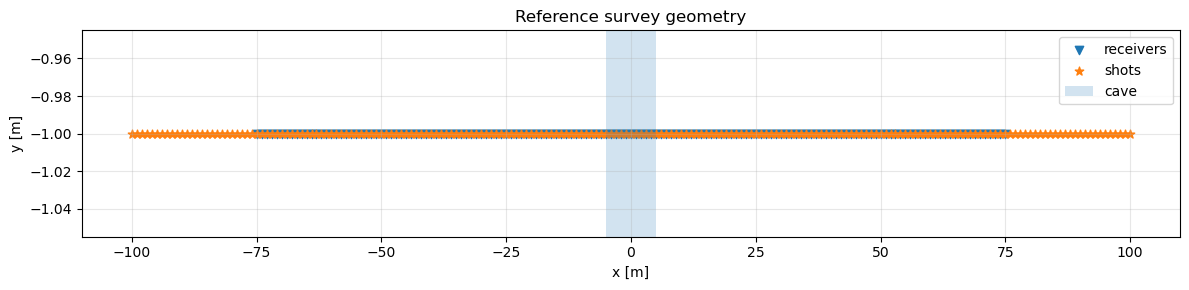

In [6]:
def plot_case_geometry(case_tables, cfg):
    """Plot receiver and shot positions for all acquisition cases."""
    for case_name, tables in case_tables.items():
        rec = tables["receivers"]
        sho = tables["shots"]

        fig, ax = plt.subplots(figsize=(12, 3))
        for array_name, sub in rec.groupby("array"):
            ax.scatter(sub["x_m"], sub["y_m"], marker="v", label=f"{array_name} receivers")
        ax.scatter(sho["x_m"], sho["y_m"], marker="*", s=90, label="shots")

        cave = cfg["cave"]
        ax.axvspan(cave["x_min_m"], cave["x_max_m"], alpha=0.15, label="cave x-range")
        ax.axvline(0.0, linestyle="--", linewidth=1, label="x=0")

        ax.set_xlabel("x [m]")
        ax.set_ylabel("PyGIMLi y [m]")
        ax.set_title(f"Survey geometry: {case_name}")
        ax.legend(loc="best")
        ax.grid(True, alpha=0.3)
        plt.tight_layout()


fig, ax = plt.subplots(figsize=(12, 3))

ax.scatter(receivers["x_m"], receivers["y_m"], marker="v", label="receivers")
ax.scatter(shots["x_m"], shots["y_m"], marker="*", s=40, label="shots")

cave = cfg["cave"]
ax.axvspan(cave["x_min_m"], cave["x_max_m"], alpha=0.2, label="cave")

ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_title("Reference survey geometry")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()

## 5. Create explicit PyGIMLi shot-receiver schemes

We create the `s` and `g` fields explicitly because the geometry includes
off-end shots and shots that do not necessarily coincide with receiver positions.

In [7]:
def make_explicit_tt_scheme(shots, receivers):
    """Create a PyGIMLi travel-time scheme for arbitrary shots and receivers."""
    data = pg.DataContainer()
    data.registerSensorIndex("s")
    data.registerSensorIndex("g")

    sensor_lookup = {}

    def add_sensor(x, y):
        key = (round(float(x), 6), round(float(y), 6))
        if key not in sensor_lookup:
            sensor_lookup[key] = data.createSensor([float(x), float(y), 0.0])
        return int(sensor_lookup[key])

    shot_sensor_ids = [add_sensor(row["x_m"], row["y_m"]) for _, row in shots.iterrows()]
    receiver_sensor_ids = [add_sensor(row["x_m"], row["y_m"]) for _, row in receivers.iterrows()]

    S, G = [], []
    for sid in shot_sensor_ids:
        for gid in receiver_sensor_ids:
            if sid != gid:
                S.append(sid)
                G.append(gid)

    data.resize(len(S))
    data.set("s", S)
    data.set("g", G)
    data.set("valid", np.ones(len(S)))
    return data


for case_name, tables in case_tables.items():
    scheme = make_explicit_tt_scheme(tables["shots"], tables["receivers"])
    tables["scheme"] = scheme
    print(f"{case_name:9s}: {scheme.sensorCount():3d} unique sensors, {scheme.size():5d} travel-time pairs")

NameError: name 'case_tables' is not defined

## 6. Build PyGIMLi geometry and meshes from the shared YAML

In [ ]:
def make_layer_geometry(cfg, pgcfg):
    """Create polygon geometry for all earth_model layers."""
    x0 = float(cfg["domain"]["x_min_m"])
    x1 = float(cfg["domain"]["x_max_m"])

    geom = None
    for marker, layer in enumerate(cfg["earth_model"]["layers"], start=1):
        top = depth_to_y(layer["z_min_m"])
        bottom = depth_to_y(layer["z_max_m"])

        poly = mt.createPolygon(
            [[x0, top], [x1, top], [x1, bottom], [x0, bottom]],
            isClosed=True,
            marker=marker,
            area=pgcfg["mesh_area_m2"],
        )

        geom = poly if geom is None else geom + poly

    return geom


def make_cave_buffer_geometry(cfg, pgcfg, marker):
    """Create a refinement region around the cave without changing material properties."""
    cave = cfg["cave"]
    buffer_m = float(pgcfg.get("cave_buffer_m", 0.0))
    if buffer_m <= 0:
        return None

    x0 = float(cave["x_min_m"]) - buffer_m
    x1 = float(cave["x_max_m"]) + buffer_m
    z0 = max(float(cfg["domain"]["z_min_m"]), float(cave["z_min_m"]) - buffer_m)
    z1 = min(float(cfg["domain"]["z_max_m"]), float(cave["z_max_m"]) + buffer_m)

    return mt.createPolygon(
        [[x0, depth_to_y(z0)], [x1, depth_to_y(z0)], [x1, depth_to_y(z1)], [x0, depth_to_y(z1)]],
        isClosed=True,
        marker=marker,
        area=pgcfg["cave_buffer_mesh_area_m2"],
    )


def make_cave_geometry(cfg, pgcfg, marker):
    """Create cave/void geometry from the shared YAML."""
    cave = cfg["cave"]
    geometry = cave.get("geometry", "rectangle").lower()

    if geometry == "rectangle":
        x0 = float(cave["x_min_m"])
        x1 = float(cave["x_max_m"])
        top = depth_to_y(cave["z_min_m"])
        bottom = depth_to_y(cave["z_max_m"])

        return mt.createPolygon(
            [[x0, top], [x1, top], [x1, bottom], [x0, bottom]],
            isClosed=True,
            marker=marker,
            area=pgcfg["cave_mesh_area_m2"],
        )

    if geometry in ("circle", "ellipse"):
        cx = float(cave.get("center_x_m", 0.5 * (cave["x_min_m"] + cave["x_max_m"])))
        cz = float(cave.get("center_z_m", 0.5 * (cave["z_min_m"] + cave["z_max_m"])))
        rx = float(cave.get("radius_x_m", 0.5 * (cave["x_max_m"] - cave["x_min_m"])))
        rz = float(cave.get("radius_z_m", 0.5 * (cave["z_max_m"] - cave["z_min_m"])))

        theta = np.linspace(0, 2 * np.pi, int(cave.get("n_segments", 64)), endpoint=False)
        points = np.column_stack([cx + rx * np.cos(theta), depth_to_y(cz) + rz * np.sin(theta)])

        return mt.createPolygon(
            points.tolist(),
            isClosed=True,
            marker=marker,
            area=pgcfg["cave_mesh_area_m2"],
        )

    raise ValueError(f"Unsupported cave geometry: {geometry}")


def make_pygimli_geometry(cfg, pgcfg, scheme, with_cave=True):
    """Create complete PyGIMLi geometry from shared YAML."""
    geom = make_layer_geometry(cfg, pgcfg)

    cave_marker = len(cfg["earth_model"]["layers"]) + 1
    buffer_marker = cave_marker + 1

    # Add cave-vicinity refinement region first, then cave itself.
    # The buffer is assigned normal layer material properties later.
    buffer_geom = make_cave_buffer_geometry(cfg, pgcfg, marker=buffer_marker)
    if buffer_geom is not None:
        geom += buffer_geom

    if with_cave:
        geom += make_cave_geometry(cfg, pgcfg, marker=cave_marker)

    for pos in scheme.sensors():
        geom.createNode([pos.x(), pos.y()])

    return geom, cave_marker, buffer_marker


def make_mesh_from_yaml(cfg, pgcfg, scheme, with_cave=True):
    """Create PyGIMLi mesh from YAML geometry."""
    geom, cave_marker, buffer_marker = make_pygimli_geometry(cfg, pgcfg, scheme, with_cave=with_cave)
    mesh = mt.createMesh(
        geom,
        quality=pgcfg["mesh_quality"],
        area=pgcfg["mesh_area_m2"],
        smooth=[1, 10],
    )
    return geom, mesh, cave_marker, buffer_marker


geom_no_cave, mesh_no_cave, cave_marker, buffer_marker = make_mesh_from_yaml(cfg, pgcfg, scheme, with_cave=False)
geom_with_cave, mesh_with_cave, cave_marker, buffer_marker = make_mesh_from_yaml(cfg, pgcfg, scheme, with_cave=True)

print(mesh_no_cave)
print(mesh_with_cave)
print(f"Cave marker: {cave_marker}")
print(f"Cave buffer marker: {buffer_marker}")

## 7. Build cell-wise model arrays from the shared YAML

In [ ]:
def build_cell_models_from_yaml(mesh, cfg, cave_marker, with_cave=True):
    """
    Build Vp, Vs, density, and Q arrays from shared YAML.

    Only cells with cave_marker get water properties. Cave-buffer cells use
    ordinary layer properties based on depth, but have a finer mesh.
    """
    markers = np.asarray(mesh.cellMarkers(), dtype=int)

    vp = np.zeros(mesh.cellCount(), dtype=float)
    vs = np.zeros(mesh.cellCount(), dtype=float)
    rho = np.zeros(mesh.cellCount(), dtype=float)
    qkappa = np.zeros(mesh.cellCount(), dtype=float)
    qmu = np.zeros(mesh.cellCount(), dtype=float)

    cave_mat = cave_material(cfg)

    for i, cell in enumerate(mesh.cells()):
        marker = int(markers[i])
        depth = y_to_depth(cell.center().y())

        if with_cave and marker == cave_marker:
            vp[i] = cave_mat["vp"]
            vs[i] = cave_mat["vs"]
            rho[i] = cave_mat["rho"]
            qkappa[i] = cave_mat["qkappa"]
            qmu[i] = cave_mat["qmu"]
        else:
            mat = material_properties_at_depth(cfg, depth)
            vp[i] = mat["vp"]
            vs[i] = mat["vs"]
            rho[i] = mat["rho"]
            qkappa[i] = mat["qkappa"]
            qmu[i] = mat["qmu"]

    return {
        "vp": vp,
        "vs": vs,
        "rho": rho,
        "qkappa": qkappa,
        "qmu": qmu,
        "markers": markers,
    }


model_no_cave = build_cell_models_from_yaml(mesh_no_cave, cfg, cave_marker, with_cave=False)
model_with_cave = build_cell_models_from_yaml(mesh_with_cave, cfg, cave_marker, with_cave=True)

print("Vp no cave:", model_no_cave["vp"].min(), model_no_cave["vp"].max())
print("Vp with cave:", model_with_cave["vp"].min(), model_with_cave["vp"].max())
print("No-cave markers:", np.unique(mesh_no_cave.cellMarkers(), return_counts=True))
print("With-cave markers:", np.unique(mesh_with_cave.cellMarkers(), return_counts=True))

## 8. Plotting and data-container helpers

In [ ]:
def draw_sensors(ax, scheme):
    """Draw PyGIMLi scheme sensor positions."""
    pg.viewer.mpl.drawSensors(
        ax,
        scheme.sensors(),
        diam=1.0,
        facecolor="white",
        edgecolor="black",
    )


def plot_cell_model(mesh, values, scheme=None, title="", label="", cmin=None, cmax=None):
    fig, ax = plt.subplots(figsize=(12, 4))
    ax, cb = pg.show(
        mesh,
        values,
        ax=ax,
        colorBar=True,
        label=label,
        logScale=False,
        cMin=cmin,
        cMax=cmax,
    )
    if scheme is not None:
        draw_sensors(ax, scheme)
    ax.set_title(title)
    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")
    plt.tight_layout()
    return ax


def set_positive_tt_errors(data, relative_error=0.03, absolute_error_s=0.001):
    """
    Ensure PyGIMLi travel-time data have strictly positive err values.

    Some PyGIMLi versions can carry a bad err token through simulation or
    TravelTimeManager setup. This function overwrites err from travel times
    and also marks only positive, finite travel times as valid.
    """
    t = np.asarray(data["t"], dtype=float)
    valid = np.isfinite(t) & (t > 0.0)

    err = np.maximum(relative_error * np.abs(t), absolute_error_s)
    err[~np.isfinite(err)] = absolute_error_s
    err[err <= 0.0] = absolute_error_s

    data.set("err", err)
    data.set("valid", valid.astype(int))
    data.removeInvalid()

    # Recompute after removeInvalid.
    t = np.asarray(data["t"], dtype=float)
    err = np.maximum(relative_error * np.abs(t), absolute_error_s)
    err[~np.isfinite(err)] = absolute_error_s
    err[err <= 0.0] = absolute_error_s
    data.set("err", err)

    return data


def copy_tt_data_with_positive_errors(data, relative_error=0.03, absolute_error_s=0.001):
    """
    Return a fresh DataContainer copy with clean positive errors.

    This avoids cases where TravelTimeManager mutates or misinterprets an
    existing container's err token.
    """
    clean = pg.DataContainer(data)
    return set_positive_tt_errors(
        clean,
        relative_error=relative_error,
        absolute_error_s=absolute_error_s,
    )

def simulate_first_arrivals(mesh, vp, scheme, pgcfg, add_noise=True):
    """Run PyGIMLi travel-time simulation and attach valid positive errors."""
    data = tt.simulate(
        slowness=1.0 / vp,
        scheme=scheme,
        mesh=mesh,
        noiseLevel=pgcfg["noise_level_relative"] if add_noise else 0.0,
        noiseAbs=pgcfg["noise_abs_s"] if add_noise else 0.0,
        seed=pgcfg["seed"],
        verbose=False,
    )
    return set_positive_tt_errors(
        data,
        relative_error=pgcfg["error_relative"],
        absolute_error_s=pgcfg["error_abs_s"],
    )


def scheme_dataframe(data):
    """Convert a PyGIMLi travel-time DataContainer into a DataFrame."""
    s = np.asarray(data["s"], dtype=int)
    g = np.asarray(data["g"], dtype=int)
    t = np.asarray(data["t"], dtype=float)
    sensors = data.sensors()

    sx = np.array([sensors[i].x() for i in s], dtype=float)
    sy = np.array([sensors[i].y() for i in s], dtype=float)
    gx = np.array([sensors[i].x() for i in g], dtype=float)
    gy = np.array([sensors[i].y() for i in g], dtype=float)

    df = pd.DataFrame({
        "s": s,
        "g": g,
        "source_x_m": sx,
        "source_y_m": sy,
        "receiver_x_m": gx,
        "receiver_y_m": gy,
        "offset_m": np.sqrt((gx - sx) ** 2 + (gy - sy) ** 2),
        "midpoint_x_m": 0.5 * (sx + gx),
        "t_s": t,
    })

    try:
        if "err" in data.tokenList():
            df["err_s"] = np.asarray(data["err"], dtype=float)
    except Exception:
        pass

    return df

## 9. Run one acquisition case

In [ ]:
def run_acquisition_case(case_name, tables, cfg, pgcfg, make_plots=True, invert=True):
    """Run no-cave and with-cave forward models, residuals, and optional inversions."""
    print("=" * 80)
    print(f"Running acquisition case: {case_name}")
    print("=" * 80)

    scheme = tables["scheme"]
    case_dir = OUTPUT_DIR / case_name
    case_dir.mkdir(parents=True, exist_ok=True)

    geom0, mesh0, cave_marker = make_mesh_from_yaml(cfg, pgcfg, scheme, with_cave=False)
    geom1, mesh1, cave_marker = make_mesh_from_yaml(cfg, pgcfg, scheme, with_cave=True)

    model0 = build_cell_models_from_yaml(mesh0, cfg, cave_marker, with_cave=False)
    model1 = build_cell_models_from_yaml(mesh1, cfg, cave_marker, with_cave=True)

    print("No-cave marker summary:", summarize_markers(mesh0, cave_marker))
    print("With-cave marker summary:", summarize_markers(mesh1, cave_marker))
    print(f"No-cave mesh: {mesh0.cellCount()} cells, {mesh0.nodeCount()} nodes")
    print(f"With-cave mesh: {mesh1.cellCount()} cells, {mesh1.nodeCount()} nodes")

    vp_min = min(model0["vp"].min(), model1["vp"].min())
    vp_max = max(model0["vp"].max(), model1["vp"].max())

    if make_plots:
        plot_cell_model(mesh0, model0["vp"], scheme=scheme, title=f"{case_name}: Vp without cave", label="Vp [m/s]", cmin=vp_min, cmax=vp_max)
        plot_cell_model(mesh1, model1["vp"], scheme=scheme, title=f"{case_name}: Vp with cave", label="Vp [m/s]", cmin=vp_min, cmax=vp_max)

    data0 = simulate_first_arrivals(mesh0, model0["vp"], scheme, pgcfg, add_noise=True)
    data1 = simulate_first_arrivals(mesh1, model1["vp"], scheme, pgcfg, add_noise=True)

    print("Error range, no cave:", float(np.min(data0["err"])), float(np.max(data0["err"])))
    print("Error range, with cave:", float(np.min(data1["err"])), float(np.max(data1["err"])))

    df0 = scheme_dataframe(data0).rename(columns={"t_s": "t_no_cave_s"})
    df1 = scheme_dataframe(data1).rename(columns={"t_s": "t_with_cave_s"})

    df_compare = df0[[
        "s", "g", "source_x_m", "source_y_m", "receiver_x_m", "receiver_y_m",
        "offset_m", "midpoint_x_m", "t_no_cave_s"
    ]].merge(
        df1[["s", "g", "t_with_cave_s"]],
        on=["s", "g"],
        how="inner",
    )
    df_compare["dt_s"] = df_compare["t_with_cave_s"] - df_compare["t_no_cave_s"]
    df_compare["dt_ms"] = 1000.0 * df_compare["dt_s"]
    df_compare["percent_change"] = 100.0 * df_compare["dt_s"] / df_compare["t_no_cave_s"]

    df_compare.to_csv(case_dir / "with_cave_minus_without_cave_traveltimes.csv", index=False)
    tables["receivers"].to_csv(case_dir / "receivers.csv", index=False)
    tables["shots"].to_csv(case_dir / "shots.csv", index=False)

    if make_plots:
        fig, ax = plt.subplots(figsize=(10, 5))
        sc = ax.scatter(df_compare["midpoint_x_m"], df_compare["offset_m"], c=df_compare["dt_ms"], s=20)
        cb = plt.colorbar(sc, ax=ax)
        cb.set_label("with cave - without cave travel time [ms]")
        cave = cfg["cave"]
        ax.axvspan(cave["x_min_m"], cave["x_max_m"], alpha=0.15, label="cave x-range")
        ax.set_xlabel("source-receiver midpoint x [m]")
        ax.set_ylabel("source-receiver offset [m]")
        ax.set_title(f"{case_name}: cave travel-time perturbation")
        ax.legend()
        plt.tight_layout()

        fig, ax = plt.subplots(figsize=(10, 5))
        ax.scatter(df_compare["offset_m"], df_compare["dt_ms"], s=20, alpha=0.7)
        ax.axhline(0, linestyle="--", linewidth=1)
        ax.set_xlabel("source-receiver offset [m]")
        ax.set_ylabel("with cave - without cave travel time [ms]")
        ax.set_title(f"{case_name}: residual versus offset")
        plt.tight_layout()

    results = {
        "case_name": case_name,
        "scheme": scheme,
        "mesh_no_cave": mesh0,
        "mesh_with_cave": mesh1,
        "model_no_cave": model0,
        "model_with_cave": model1,
        "data_no_cave": data0,
        "data_with_cave": data1,
        "df_compare": df_compare,
    }


    if invert and pgcfg["inversion"].get("run", True):
        for label, data in [
            ("inversion_no_cave", data0),
            ("inversion_with_cave", data1),
        ]:
            try:
                pretty = "without cave" if label.endswith("no_cave") else "with cave"
                results[label] = invert_travel_times(data, pgcfg, f"{case_name}: inversion {pretty}")
            except Exception as exc:
                print(f"WARNING: {case_name} {label} failed: {exc}")
                results[label] = None
        return results

## 10. Inversion helper

This uses the positive `err` values assigned after forward modelling, avoiding
the negative/non-positive error issue that can stop `TravelTimeManager.invert()`.

In [ ]:
def invert_travel_times(data, pgcfg, title):
    """
    Invert travel times with TravelTimeManager.

    The cleaned data container is passed explicitly into mgr.invert(data=...)
    and the error vector is also passed as err=... to avoid PyGIMLi version
    issues where the DataContainer constructor can preserve a bad internal
    error vector.
    """
    clean_data = copy_tt_data_with_positive_errors(
        data,
        relative_error=pgcfg["error_relative"],
        absolute_error_s=pgcfg["error_abs_s"],
    )

    err = np.asarray(clean_data["err"], dtype=float)
    t = np.asarray(clean_data["t"], dtype=float)

    print(f"{title}")
    print(f"  travel-time range: {float(np.min(t)):.6g} to {float(np.max(t)):.6g} s")
    print(f"  error range before inversion: {float(np.min(err)):.6g} to {float(np.max(err)):.6g} s")
    print(f"  data count: {clean_data.size()}")

    if np.any(~np.isfinite(err)) or np.any(err <= 0):
        raise ValueError("Error vector still contains non-positive or non-finite values before inversion.")

    mgr = tt.TravelTimeManager()
    inv = pgcfg["inversion"]

    velocity = mgr.invert(
        data=clean_data,
        err=err,
        secNodes=inv["sec_nodes"],
        paraMaxCellSize=inv["para_max_cell_size_m2"],
        maxIter=inv["max_iter"],
        lam=inv["lam"],
        verbose=True,
    )

    ax, _ = mgr.showResult(logScale=False)
    ax.set_title(title)
    plt.tight_layout()

    mgr.showFit(firstPicks=True)
    plt.title(f"Data fit: {title}")

    return {"manager": mgr, "velocity": velocity, "data": clean_data}

## 11. Run all three acquisition cases

Set `RUN_INVERSIONS = False` if you want to test only the forward models first.

## Legacy multi-case runner

Skipped in this reference-model notebook. Use the reference workflow below.

In [ ]:
# Legacy multi-case runner intentionally disabled for the reference model.
# The reference model uses one oversampled geometry and saves the full table.
results = {}

## 12. Compare case-level detectability metrics

In [ ]:
summary_rows = []
for case_name, result in results.items():
    df = result["df_compare"]
    summary_rows.append({
        "case": case_name,
        "n_receivers": len(case_tables[case_name]["receivers"]),
        "n_shots": len(case_tables[case_name]["shots"]),
        "n_traveltimes": len(df),
        "mean_abs_dt_ms": float(np.mean(np.abs(df["dt_ms"]))),
        "median_abs_dt_ms": float(np.median(np.abs(df["dt_ms"]))),
        "p95_abs_dt_ms": float(np.percentile(np.abs(df["dt_ms"]), 95)),
        "max_abs_dt_ms": float(np.max(np.abs(df["dt_ms"]))),
    })

summary = pd.DataFrame(summary_rows)
summary.to_csv(OUTPUT_DIR / "case_detectability_summary.csv", index=False)
display(summary)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(summary["case"], summary["p95_abs_dt_ms"])
ax.set_ylabel("95th percentile |dt| [ms]")
ax.set_title("Cave detectability proxy by acquisition case")
plt.tight_layout()

In [ ]:
df_compare[summary["offset_m"] > 40]

## 13. Export shared survey tables

In [ ]:
for case_name, tables in case_tables.items():
    case_dir = OUTPUT_DIR / case_name
    case_dir.mkdir(parents=True, exist_ok=True)
    tables["receivers"].to_csv(case_dir / "receivers.csv", index=False)
    tables["shots"].to_csv(case_dir / "shots.csv", index=False)

layer_rows = []
for i, layer in enumerate(cfg["earth_model"]["layers"], start=1):
    row = dict(layer)
    row["marker"] = i
    layer_rows.append(row)
pd.DataFrame(layer_rows).to_csv(OUTPUT_DIR / "layers_from_shared_yaml.csv", index=False)

cave_row = dict(cfg["cave"])
if "water" in cave_row:
    water = cave_row.pop("water")
    for k, v in water.items():
        cave_row[f"water_{k}"] = v
cave_row["marker"] = len(cfg["earth_model"]["layers"]) + 1
pd.DataFrame([cave_row]).to_csv(OUTPUT_DIR / "cave_from_shared_yaml.csv", index=False)

print(f"Wrote outputs to {OUTPUT_DIR.resolve()}")

## Reference model: full forward travel-time dataset

This computes the full no-cave and with-cave travel-time tables for the
oversampled reference survey. Later survey-design experiments should subset
the saved tables rather than recomputing the forward problem, unless the
model, mesh, or physics changes.

In [ ]:
reference_dir = OUTPUT_DIR / "reference_model"
reference_dir.mkdir(parents=True, exist_ok=True)

data_no_cave = simulate_first_arrivals(
    mesh_no_cave,
    model_no_cave["vp"],
    scheme,
    pgcfg,
    add_noise=True,
)

data_with_cave = simulate_first_arrivals(
    mesh_with_cave,
    model_with_cave["vp"],
    scheme,
    pgcfg,
    add_noise=True,
)

print("No-cave data:", data_no_cave)
print("With-cave data:", data_with_cave)
print("Error range, no cave:", float(np.min(data_no_cave["err"])), float(np.max(data_no_cave["err"])))
print("Error range, with cave:", float(np.min(data_with_cave["err"])), float(np.max(data_with_cave["err"])))

In [ ]:
df0 = scheme_dataframe(data_no_cave).rename(columns={"t_s": "t_no_cave_s"})
df1 = scheme_dataframe(data_with_cave).rename(columns={"t_s": "t_with_cave_s"})

df_reference = df0[[
    "s", "g", "source_x_m", "source_y_m", "receiver_x_m", "receiver_y_m",
    "offset_m", "midpoint_x_m", "t_no_cave_s"
]].merge(
    df1[["s", "g", "t_with_cave_s"]],
    on=["s", "g"],
    how="inner",
)

df_reference["dt_s"] = df_reference["t_with_cave_s"] - df_reference["t_no_cave_s"]
df_reference["dt_ms"] = 1000.0 * df_reference["dt_s"]
df_reference["percent_change"] = 100.0 * df_reference["dt_s"] / df_reference["t_no_cave_s"]

# Add shot/receiver x metadata as rounded values for easy decimation.
df_reference["source_x_round_m"] = df_reference["source_x_m"].round(6)
df_reference["receiver_x_round_m"] = df_reference["receiver_x_m"].round(6)

reference_csv = reference_dir / "reference_full_with_cave_minus_without_cave_traveltimes.csv"
df_reference.to_csv(reference_csv, index=False)

receivers.to_csv(reference_dir / "reference_receivers.csv", index=False)
shots.to_csv(reference_dir / "reference_shots.csv", index=False)

print(f"Wrote {reference_csv}")
print(df_reference["dt_ms"].describe())
display(df_reference.head())

In [ ]:
fig, ax = plt.subplots(figsize=(11, 5))
sc = ax.scatter(
    df_reference["midpoint_x_m"],
    df_reference["offset_m"],
    c=df_reference["dt_ms"],
    s=8,
    alpha=0.8,
)
cb = plt.colorbar(sc, ax=ax)
cb.set_label("with cave - without cave travel time [ms]")

cave = cfg["cave"]
ax.axvspan(cave["x_min_m"], cave["x_max_m"], alpha=0.15, label="cave x-range")
ax.set_xlabel("source-receiver midpoint x [m]")
ax.set_ylabel("source-receiver offset [m]")
ax.set_title("Reference model: cave travel-time perturbation")
ax.legend()
plt.tight_layout()

## Decimation from the reference table

The full table can be subset without recomputing the forward model. For example,
this cell emulates receiver and shot spacing/aperture changes using modulo-style
selection on the integer-metre reference coordinates.

In [ ]:
def subset_reference_table(
    df,
    *,
    receiver_spacing_m=1,
    shot_spacing_m=1,
    receiver_halfwidth_m=75,
    shot_halfwidth_m=100,
):
    """Subset the full reference table by receiver/shot spacing and aperture."""
    sx = df["source_x_round_m"]
    gx = df["receiver_x_round_m"]

    mask = (
        (sx.abs() <= shot_halfwidth_m)
        & (gx.abs() <= receiver_halfwidth_m)
        & (np.isclose(np.mod(sx + 1000.0, shot_spacing_m), 0.0))
        & (np.isclose(np.mod(gx + 1000.0, receiver_spacing_m), 0.0))
    )

    return df.loc[mask].copy()


decimation_rows = []
decim_cfg = pgcfg.get("decimation_experiments", cfg.get("pygimli", {}).get("decimation_experiments", {}))

receiver_spacings = decim_cfg.get("receiver_spacings_m", [1, 2, 4, 5, 10])
shot_spacings = decim_cfg.get("shot_spacings_m", [1, 2, 4, 5, 10])
receiver_halfwidths = decim_cfg.get("receiver_halfwidths_m", [35, 50, 75])
shot_halfwidths = decim_cfg.get("shot_halfwidths_m", [60, 80, 100])

for rspace in receiver_spacings:
    for sspace in shot_spacings:
        for rhw in receiver_halfwidths:
            for shw in shot_halfwidths:
                sub = subset_reference_table(
                    df_reference,
                    receiver_spacing_m=rspace,
                    shot_spacing_m=sspace,
                    receiver_halfwidth_m=rhw,
                    shot_halfwidth_m=shw,
                )
                if len(sub) == 0:
                    continue
                decimation_rows.append({
                    "receiver_spacing_m": rspace,
                    "shot_spacing_m": sspace,
                    "receiver_halfwidth_m": rhw,
                    "shot_halfwidth_m": shw,
                    "n_traveltimes": len(sub),
                    "p95_abs_dt_ms": float(np.percentile(np.abs(sub["dt_ms"]), 95)),
                    "max_abs_dt_ms": float(np.max(np.abs(sub["dt_ms"]))),
                    "mean_abs_dt_ms": float(np.mean(np.abs(sub["dt_ms"]))),
                })

df_decimation = pd.DataFrame(decimation_rows)
decimation_csv = reference_dir / "reference_decimation_detectability_summary.csv"
df_decimation.to_csv(decimation_csv, index=False)

print(f"Wrote {decimation_csv}")
display(df_decimation.sort_values("p95_abs_dt_ms", ascending=False).head(20))